# Midterm Project – Real Estate Exploratory Data Analysis and Preprocessing

**Course:** ITAI 1371 – Introduction to Machine Learning  
**Dataset Source:** Kaggle  
**Dataset:** Real Estate Sales  
**Original Dataset URL:** https://www.kaggle.com/datasets/nrng19/real-estate

## Project Goal

The goal of this project is to explore, clean, and preprocess a real estate dataset using Python.

For this Midterm, `real_estate_midterm_raw.csv` will be treated as the raw working dataset. All data preparation will be performed using Python without manually changing the dataset.

The dataset will first be divided into 70% training data and 30% testing data. Exploratory Data Analysis and preprocessing will be performed only on the training data, while the testing data will remain untouched.

The future machine learning goal is to predict **Sale Amount**, making this a **Supervised Learning – Regression** problem.

In [4]:
# 1. Load Data and Create Training and Testing Sets

#This section loads the raw working dataset and reviews its basic structure.
#The dataset is then divided into 70% training data and 30% testing data before any EDA or preprocessing is performed.
#The testing dataset is saved immediately and will remain untouched.


# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Load the raw working dataset

df = pd.read_csv("real_estate_midterm_raw.csv")

print("Dataset loaded successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nSample Data:")
display(df.head())

Dataset loaded successfully!

Dataset Shape:
(25000, 10)

Column Names:
['Serial Number', 'List Year', 'Date Recorded', 'Town', 'Address', 'Assessed Value', 'Sale Amount', 'Sales Ratio', 'Property Type', 'Residential Type']

Sample Data:


,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
0,18364,2018,09/03/2019,North Haven,67 MONTOWESE AVE,148960.0,202000.0,0.737400,Single Family,Single Family
1,21218,2021,04/25/2022,Bethel,526 COPPER SQUARE DRIVE,212730.0,382000.0,0.556800,Residential,Condo
2,80487,2008,07/31/2009,Fairfield,245 UNQUOWA ROAD #109,206220.0,325000.0,0.634523,Condo,Condo
3,70264,2007,08/15/2008,Darien,248 NOROTON AVE,423430.0,1137100.0,0.372377,Single Family,Single Family
4,200945,2020,05/27/2021,New Haven,86 OAK RDIGE DR # 38,26670.0,75000.0,0.355600,Residential,Condo


In [5]:
# Split dataset into 70% training and 30% testing

train_df, test_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42
)

# Reset indexes

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


print("Training Data:")
print(train_df.shape)

print("\nTesting Data:")
print(test_df.shape)


# Save both raw datasets

train_df.to_csv("raw_train_data.csv", index=False)
test_df.to_csv("raw_test_data.csv", index=False)

print("\nTraining and testing datasets saved.")

Training Data:
(17500, 10)

Testing Data:
(7500, 10)

Training and testing datasets saved.


Training Dataset Shape:
(17500, 10)

Sample Training Data:


,Serial Number,List Year,Date Recorded,Town,Address,Assessed Value,Sale Amount,Sales Ratio,Property Type,Residential Type
0,200056,2020,11/23/2020,Westbrook,15 CHERRY ST,303850.0,300000.0,1.012800,Residential,Single Family
1,130172,2013,01/02/2014,Manchester,454-4 EAST CENTER STREET,47600.0,65000.0,0.732308,Condo,Condo
2,120221,2012,06/20/2013,Guilford,132 SCHOOLSIDE LN,372990.0,499000.0,0.747475,Single Family,Single Family
3,20042,2002,01/07/2003,Canterbury,BARSTOW RD,18800.0,42000.0,0.447619,NaN,NaN
4,130492,2013,06/03/2014,New Britain,529 CORBIN AVE,131460.0,240000.0,0.547750,Single Family,Single Family



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17500 entries, 0 to 17499
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Serial Number     17500 non-null  int64  
 1   List Year         17500 non-null  int64  
 2   Date Recorded     17500 non-null  object 
 3   Town              17500 non-null  object 
 4   Address           17498 non-null  object 
 5   Assessed Value    17500 non-null  float64
 6   Sale Amount       17500 non-null  float64
 7   Sales Ratio       17500 non-null  float64
 8   Property Type     10924 non-null  object 
 9   Residential Type  10703 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 1.3+ MB
Missing Values Before Cleaning:
Serial Number          0
List Year              0
Date Recorded          0
Town                   0
Address                2
Assessed Value         0
Sale Amount            0
Sales Ratio            0
Property Ty

,Serial Number,List Year,Assessed Value,Sale Amount,Sales Ratio
count,1.750000e+04,17500.000000,1.750000e+04,1.750000e+04,17500.000000
mean,4.162330e+05,2010.303257,2.817043e+05,4.051976e+05,1.796011
std,5.831941e+06,6.438612,1.406472e+06,1.775229e+06,31.686078
min,8.110000e+02,2001.000000,0.000000e+00,0.000000e+00,0.000000
25%,3.042850e+04,2004.000000,8.750000e+04,1.400000e+05,0.477763
50%,7.018900e+04,2010.000000,1.377250e+05,2.275000e+05,0.612000
75%,1.600320e+05,2016.000000,2.231150e+05,3.700000e+05,0.776059
max,2.111000e+08,2021.000000,6.023185e+07,1.523841e+08,3313.706667


Numerical Columns:
Index(['Serial Number', 'List Year', 'Assessed Value', 'Sale Amount',
       'Sales Ratio'],
      dtype='object')

Categorical Columns:
Index(['Date Recorded', 'Town', 'Address', 'Property Type',
       'Residential Type'],
      dtype='object')


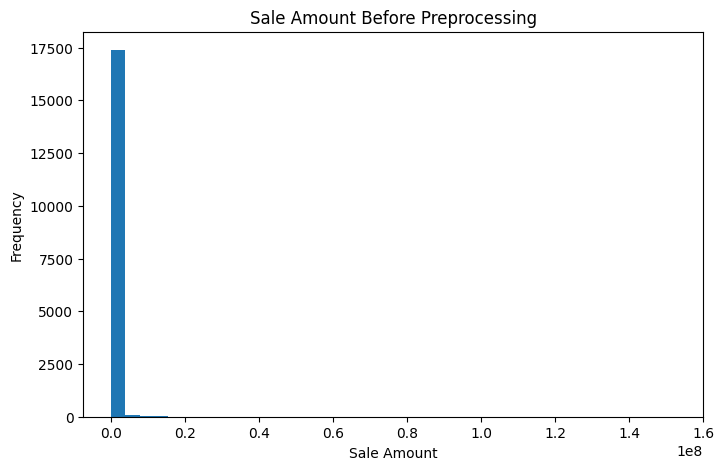

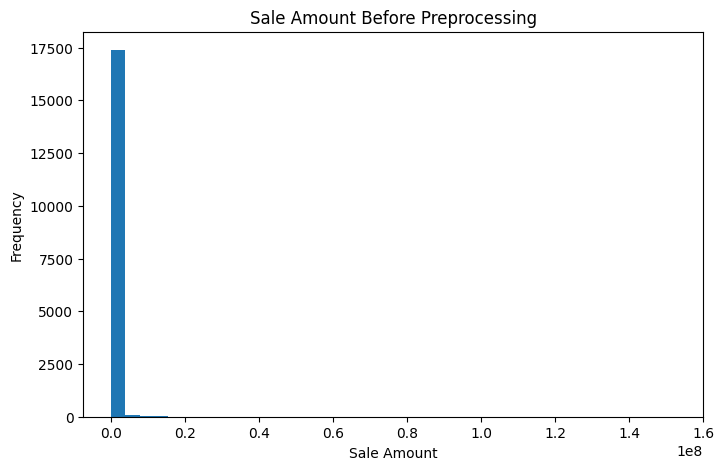

In [6]:
# 2. Exploratory Data Analysis – Training Data Only
#This section explores the training dataset before cleaning.
#We review the data structure, missing values, duplicates, numerical statistics, categorical features, and the distribution of important numerical variables.
#These observations will help determine what preprocessing is necessary.

# Review training data

print("Training Dataset Shape:")
print(train_df.shape)

print("\nSample Training Data:")
display(train_df.head())


# Review data types and non-null values

print("\nDataset Information:")
train_df.info()


# Check missing values

print("Missing Values Before Cleaning:")

print(
    train_df.isnull().sum()
)


# Check duplicate records

print("\nDuplicate Rows:")

print(
    train_df.duplicated().sum()
)


# Review numerical statistics

display(
    train_df.describe()
)

# Identify numerical and categorical columns

numerical_columns = train_df.select_dtypes(
    include="number"
).columns

categorical_columns = train_df.select_dtypes(
    include="object"
).columns


print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

# Visualize Sale Amount before preprocessing

plt.figure(figsize=(8, 5))

plt.hist(
    train_df["Sale Amount"].dropna(),
    bins=40
)

plt.title("Sale Amount Before Preprocessing")
plt.xlabel("Sale Amount")
plt.ylabel("Frequency")

plt.show()

# Visualize Sale Amount before preprocessing

plt.figure(figsize=(8, 5))

plt.hist(
    train_df["Sale Amount"].dropna(),
    bins=40
)

plt.title("Sale Amount Before Preprocessing")
plt.xlabel("Sale Amount")
plt.ylabel("Frequency")

plt.show()

In [7]:
# 3. Data Cleaning and Feature Engineering

#This section cleans the training dataset based on the problems identified during EDA.
#The process includes:
#- Removing duplicate records
#- Handling missing values
#- Checking invalid numerical values
#- Creating new features from Date Recorded
#- Removing features that are not useful for the future machine learning model

# Create a copy of the training data for cleaning

train_clean = train_df.copy()


# Remove duplicate records

train_clean = train_clean.drop_duplicates()

print("Duplicates After Cleaning:")
print(train_clean.duplicated().sum())

# Check invalid numerical values

print("Invalid Sale Amount:")
print(
    (train_clean["Sale Amount"] <= 0).sum()
)

print("\nInvalid Assessed Value:")
print(
    (train_clean["Assessed Value"] <= 0).sum()
)


# Remove missing or invalid Sale Amount records from TRAINING data

train_clean = train_clean.dropna(
    subset=["Sale Amount"]
)

train_clean = train_clean[
    train_clean["Sale Amount"] > 0
].copy()


print("Training Shape After Sale Amount Cleaning:")
print(train_clean.shape)

# Convert invalid Assessed Value records to missing values

train_clean.loc[
    train_clean["Assessed Value"] <= 0,
    "Assessed Value"
] = np.nan


# Calculate the median using training data

assessed_median = train_clean[
    "Assessed Value"
].median()


# Fill missing values with the median

train_clean["Assessed Value"] = (
    train_clean["Assessed Value"]
    .fillna(assessed_median)
)


print("Median Assessed Value:")
print(assessed_median)

print("\nMissing Assessed Values After Cleaning:")
print(
    train_clean["Assessed Value"]
    .isnull()
    .sum()
)

# Fill missing categorical values

train_clean["Town"] = (
    train_clean["Town"]
    .fillna("Unknown")
)

train_clean["Property Type"] = (
    train_clean["Property Type"]
    .fillna("Unknown")
)

train_clean["Residential Type"] = (
    train_clean["Residential Type"]
    .fillna("Unknown")
)


print("Missing Categorical Values:")

print(
    train_clean[
        [
            "Town",
            "Property Type",
            "Residential Type"
        ]
    ].isnull().sum()
)

Duplicates After Cleaning:
0
Invalid Sale Amount:
23

Invalid Assessed Value:
117
Training Shape After Sale Amount Cleaning:
(17477, 10)
Median Assessed Value:
138320.0

Missing Assessed Values After Cleaning:
0
Missing Categorical Values:
Town                0
Property Type       0
Residential Type    0
dtype: int64


In [8]:
### Feature Engineering

#The original `Date Recorded` column contains useful information.
#Sale Year and Sale Month are created from this column so the date information can later be used more easily by a machine learning model.

# Convert Date Recorded to datetime

train_clean["Date Recorded"] = pd.to_datetime(
    train_clean["Date Recorded"],
    errors="coerce"
)


# Create new date features

train_clean["Sale Year"] = (
    train_clean["Date Recorded"].dt.year
)

train_clean["Sale Month"] = (
    train_clean["Date Recorded"].dt.month
)


display(
    train_clean[
        [
            "Date Recorded",
            "Sale Year",
            "Sale Month"
        ]
    ].head()
)

# Fill missing year and month with the most common value

train_clean["Sale Year"] = (
    train_clean["Sale Year"]
    .fillna(
        train_clean["Sale Year"].mode()[0]
    )
)

train_clean["Sale Month"] = (
    train_clean["Sale Month"]
    .fillna(
        train_clean["Sale Month"].mode()[0]
    )
)



,Date Recorded,Sale Year,Sale Month
0,2020-11-23,2020,11
1,2014-01-02,2014,1
2,2013-06-20,2013,6
3,2003-01-07,2003,1
4,2014-06-03,2014,6


In [9]:
# Feature Selection

#Some original columns will not be useful for the future machine learning model.

#- `Serial Number` is only an identifier.
#- `Address` contains many unique text values.
#- `Date Recorded` has been replaced by Sale Year and Sale Month.
#- `Sales Ratio` is directly related to Sale Amount and could introduce data leakage.

# Remove unnecessary features

train_clean = train_clean.drop(
    columns=[
        "Serial Number",
        "Address",
        "Date Recorded",
        "Sales Ratio"
    ]
)


print("Remaining Columns:")

print(
    train_clean.columns.tolist()
)

display(train_clean.head())



Remaining Columns:
['List Year', 'Town', 'Assessed Value', 'Sale Amount', 'Property Type', 'Residential Type', 'Sale Year', 'Sale Month']


,List Year,Town,Assessed Value,Sale Amount,Property Type,Residential Type,Sale Year,Sale Month
0,2020,Westbrook,303850.0,300000.0,Residential,Single Family,2020,11
1,2013,Manchester,47600.0,65000.0,Condo,Condo,2014,1
2,2012,Guilford,372990.0,499000.0,Single Family,Single Family,2013,6
3,2002,Canterbury,18800.0,42000.0,Unknown,Unknown,2003,1
4,2013,New Britain,131460.0,240000.0,Single Family,Single Family,2014,6


Before and After Normalization:


,Assessed Value,Assessed Value Log
0,303850.0,12.624293
1,47600.0,10.770609
2,372990.0,12.829310
3,18800.0,9.841665
4,131460.0,11.786466


,Assessed Value,Assessed Value Log,Assessed Value Scaled
0,303850.0,12.624293,0.781970
1,47600.0,10.770609,-1.133924
2,372990.0,12.829310,0.993867
3,18800.0,9.841665,-2.094043
4,131460.0,11.786466,-0.083975


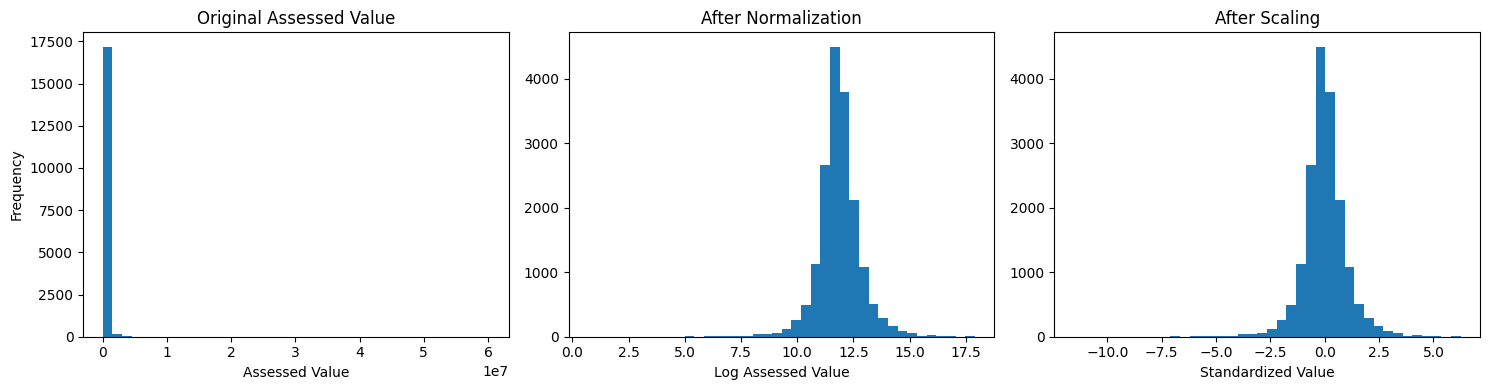

In [15]:
# 4. Data Transformation
# This section prepares the cleaned training dataset for future machine learning.
#The process includes:
#- Normalization
#- Feature Scaling
#- One-Hot Encoding
#These transformations are performed only on the training data.

# Apply log normalization to Assessed Value

train_clean["Assessed Value Log"] = np.log1p(
    train_clean["Assessed Value"]
)


print("Before and After Normalization:")

display(
    train_clean[
        [
            "Assessed Value",
            "Assessed Value Log"
        ]
    ].head()
)

# Create StandardScaler

scaler = StandardScaler()


# Scale the normalized Assessed Value

train_clean["Assessed Value Scaled"] = (
    scaler.fit_transform(
        train_clean[
            ["Assessed Value Log"]
        ]
    )
)


display(
    train_clean[
        [
            "Assessed Value",
            "Assessed Value Log",
            "Assessed Value Scaled"
        ]
    ].head()
)

# Compare Assessed Value before and after preprocessing

plt.figure(figsize=(15, 4))


# Original distribution

plt.subplot(1, 3, 1)

plt.hist(
    train_clean["Assessed Value"],
    bins=40
)

plt.title("Original Assessed Value")
plt.xlabel("Assessed Value")
plt.ylabel("Frequency")


# Normalized distribution

plt.subplot(1, 3, 2)

plt.hist(
    train_clean["Assessed Value Log"],
    bins=40
)

plt.title("After Normalization")
plt.xlabel("Log Assessed Value")


# Scaled distribution

plt.subplot(1, 3, 3)

plt.hist(
    train_clean["Assessed Value Scaled"],
    bins=40
)

plt.title("After Scaling")
plt.xlabel("Standardized Value")


plt.tight_layout()
plt.show()




In [11]:
# One-Hot Encoding
#Categorical text features need to be converted into numerical values before they can later be used by machine learning models.
# One-Hot Encoding is applied to Town, Property Type, and Residential Type.

# Apply One-Hot Encoding

train_encoded = pd.get_dummies(
    train_clean,
    columns=[
        "Town",
        "Property Type",
        "Residential Type"
    ],
    drop_first=True,
    dtype=int
)


print("Shape Before Encoding:")
print(train_clean.shape)

print("\nShape After Encoding:")
print(train_encoded.shape)


display(train_encoded.head())


# Keep the final scaled version of Assessed Value

train_encoded = train_encoded.drop(
    columns=[
        "Assessed Value",
        "Assessed Value Log"
    ]
)


print("Final Columns:")
print(train_encoded.columns.tolist())


Shape Before Encoding:
(17477, 10)

Shape After Encoding:
(17477, 190)


,List Year,Assessed Value,Sale Amount,Sale Year,Sale Month,Assessed Value Log,Assessed Value Scaled,Town_Ansonia,Town_Ashford,Town_Avon,...,Property Type_Single Family,Property Type_Three Family,Property Type_Two Family,Property Type_Unknown,Property Type_Vacant Land,Residential Type_Four Family,Residential Type_Single Family,Residential Type_Three Family,Residential Type_Two Family,Residential Type_Unknown
0,2020,303850.0,300000.0,2020,11,12.624293,0.781970,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,2013,47600.0,65000.0,2014,1,10.770609,-1.133924,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2012,372990.0,499000.0,2013,6,12.829310,0.993867,0,0,0,...,1,0,0,0,0,0,1,0,0,0
3,2002,18800.0,42000.0,2003,1,9.841665,-2.094043,0,0,0,...,0,0,0,1,0,0,0,0,0,1
4,2013,131460.0,240000.0,2014,6,11.786466,-0.083975,0,0,0,...,1,0,0,0,0,0,1,0,0,0


Final Columns:
['List Year', 'Sale Amount', 'Sale Year', 'Sale Month', 'Assessed Value Scaled', 'Town_Ansonia', 'Town_Ashford', 'Town_Avon', 'Town_Barkhamsted', 'Town_Beacon Falls', 'Town_Berlin', 'Town_Bethany', 'Town_Bethel', 'Town_Bethlehem', 'Town_Bloomfield', 'Town_Bolton', 'Town_Bozrah', 'Town_Branford', 'Town_Bridgeport', 'Town_Bridgewater', 'Town_Bristol', 'Town_Brookfield', 'Town_Brooklyn', 'Town_Burlington', 'Town_Canaan', 'Town_Canterbury', 'Town_Canton', 'Town_Chaplin', 'Town_Cheshire', 'Town_Chester', 'Town_Clinton', 'Town_Colchester', 'Town_Colebrook', 'Town_Columbia', 'Town_Cornwall', 'Town_Coventry', 'Town_Cromwell', 'Town_Danbury', 'Town_Darien', 'Town_Deep River', 'Town_Derby', 'Town_Durham', 'Town_East Granby', 'Town_East Haddam', 'Town_East Hampton', 'Town_East Hartford', 'Town_East Haven', 'Town_East Lyme', 'Town_East Windsor', 'Town_Eastford', 'Town_Easton', 'Town_Ellington', 'Town_Enfield', 'Town_Essex', 'Town_Fairfield', 'Town_Farmington', 'Town_Franklin', 'Town

In [12]:
# 5. Final Data Quality Check and Export
# The processed training dataset is reviewed to confirm that the required preprocessing steps have been completed.
# The final clean dataset will then be saved for future machine learning exercises.

# Final quality check

print("Final Training Dataset Shape:")
print(train_encoded.shape)


print("\nTotal Missing Values:")
print(
    train_encoded.isnull().sum().sum()
)


print("\nRemaining Text Columns:")
print(
    train_encoded
    .select_dtypes(include="object")
    .columns
    .tolist()
)


print("\nFinal Sample Data:")
display(train_encoded.head())

Final Training Dataset Shape:
(17477, 188)

Total Missing Values:
0

Remaining Text Columns:
[]

Final Sample Data:


,List Year,Sale Amount,Sale Year,Sale Month,Assessed Value Scaled,Town_Ansonia,Town_Ashford,Town_Avon,Town_Barkhamsted,Town_Beacon Falls,...,Property Type_Single Family,Property Type_Three Family,Property Type_Two Family,Property Type_Unknown,Property Type_Vacant Land,Residential Type_Four Family,Residential Type_Single Family,Residential Type_Three Family,Residential Type_Two Family,Residential Type_Unknown
0,2020,300000.0,2020,11,0.781970,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,2013,65000.0,2014,1,-1.133924,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2012,499000.0,2013,6,0.993867,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
3,2002,42000.0,2003,1,-2.094043,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
4,2013,240000.0,2014,6,-0.083975,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0


In [13]:
# Compare training data before and after preprocessing

print("BEFORE PREPROCESSING")

print("Shape:")
print(train_df.shape)

print("Missing Values:")
print(
    train_df.isnull().sum().sum()
)


print("\n-----------------------")


print("\nAFTER PREPROCESSING")

print("Shape:")
print(train_encoded.shape)

print("Missing Values:")
print(
    train_encoded.isnull().sum().sum()
)

# Save final cleaned training dataset

train_encoded.to_csv(
    "cleaned_train_data.csv",
    index=False
)


print("Cleaned training dataset saved successfully.")

print("Final Shape:")
print(train_encoded.shape)

BEFORE PREPROCESSING
Shape:
(17500, 10)
Missing Values:
13375

-----------------------

AFTER PREPROCESSING
Shape:
(17477, 188)
Missing Values:
0
Cleaned training dataset saved successfully.
Final Shape:
(17477, 188)


## Objective

The future goal will be to predict the sale price of a property using property and transaction characteristics.

Potential predictor features include:

- Assessed Value
- Town
- Property Type
- Residential Type
- List Year
- Sale Year
- Sale Month

`Sales Ratio` was excluded because it is directly related to Sale Amount and could introduce data leakage.

The cleaned training dataset can later be used to train and compare regression models.

The 30% testing dataset remained untouched during the Midterm and can later be prepared using the same rules learned from training data and used to evaluate the final machine learning models.

# Project Summary

For this Midterm, the Real Estate dataset was divided into 70% training data and 30% testing data before Exploratory Data Analysis.

All EDA and preprocessing were performed only on the training dataset.

The preprocessing included:

- Missing value handling
- Duplicate checking
- Invalid value checking
- Feature engineering
- Feature selection
- Normalization
- Feature scaling
- One-Hot Encoding
- Before and after visualizations

Class balancing was reviewed but was not applicable because this is a regression problem.

The testing dataset remained untouched.